In [29]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [54]:
df = pd.read_csv("/home/onyxia/work/Projet-de-Statapp---WFP-/NIGERIA_WFP_ENGINEERED.csv")

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['NAME_1', 'time']).reset_index(drop=True)

cols_proxy = [c for c in df.columns if 'proxy' in c.lower()]
df = df.drop(columns=cols_proxy)

In [31]:
df

,NAME_1,time,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,...,FPAR_Lag_2,FPAR_Lag_3,FPAR_Lag_4,FPAR_Lag_5,FPAR_Lag_6,acled_events,acled_fatalities,acled_events_cum3,acled_fatalities_cum3,acled_events_lag1
0,Abia,2023-01-01,0.296774,0.5,5.395000,7.471889,0.000016,385.566324,-71.064699,99941.271400,...,NaN,NaN,NaN,NaN,NaN,2.0,4.0,8.0,7.0,2.0
1,Abia,2023-02-01,0.401515,0.5,5.395000,7.471889,0.000014,392.934595,-69.757725,99864.297600,...,NaN,NaN,NaN,NaN,NaN,6.0,5.0,10.0,9.0,2.0
2,Abia,2023-03-01,0.281046,0.5,5.395000,7.471889,0.000026,408.719824,-44.999965,99913.329933,...,-0.551000,NaN,NaN,NaN,NaN,1.0,1.0,9.0,10.0,6.0
3,Abia,2023-04-01,0.300613,0.5,5.395000,7.471889,0.000030,416.609924,-39.776577,99798.052400,...,NaN,-0.551000,NaN,NaN,NaN,2.0,4.0,9.0,10.0,1.0
4,Abia,2023-05-01,0.226667,0.5,5.395000,7.471889,0.000039,419.145751,-35.249339,99990.250067,...,0.264333,NaN,-0.551000,NaN,NaN,3.0,3.0,6.0,8.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,Zamfara,2025-08-01,0.500000,0.5,12.281723,6.331793,0.000056,399.689712,-45.163207,96580.019643,...,-0.026667,-0.421000,0.257333,0.486000,0.307000,81.0,244.0,184.0,585.0,51.0
1076,Zamfara,2025-09-01,0.453333,0.5,12.281723,6.331793,0.000062,401.024427,-45.901838,96565.790857,...,0.138667,-0.026667,-0.421000,0.257333,0.486000,67.0,148.0,199.0,567.0,81.0
1077,Zamfara,2025-10-01,0.427673,0.5,12.281723,6.331793,0.000055,370.418978,-81.860593,96497.265000,...,0.234000,0.138667,-0.026667,-0.421000,0.257333,59.0,99.0,207.0,491.0,67.0
1078,Zamfara,2025-11-01,0.415301,0.5,12.281723,6.331793,0.000021,334.451814,-120.701201,96528.654000,...,0.441333,0.234000,0.138667,-0.026667,-0.421000,56.0,79.0,182.0,326.0,59.0


In [55]:
df = df.sort_values(['NAME_1', 'time'])
for l in [1]:
    df[f'inadequate_lag{l}'] = df.groupby('NAME_1')['inadequate'].shift(l)
df['delta_inadequate'] = df.groupby('NAME_1')['inadequate'].diff()
df['delta_inadequate_h3'] = df.groupby('NAME_1')['inadequate'].shift(-3) - df['inadequate']
df['delta_inadequate_h6'] = df.groupby('NAME_1')['inadequate'].shift(-6) - df['inadequate']

In [56]:
def analyze_optimal_lag(df, state_name, target_var='delta_inadequate',
                        climate_var='WSI', max_lag=6):
    df_state = df[df['NAME_1'] == state_name].sort_values('time').copy()
    if df_state.empty:
        return None
    lags, corrs = list(range(max_lag + 1)), []
    for lag in lags:
        col_name = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        if col_name in df_state.columns:
            valid = df_state[[target_var, col_name]].dropna()
            corrs.append(valid[target_var].corr(valid[col_name]) if len(valid) > 2 else 0)
        else:
            corrs.append(0)
    best_idx = int(np.argmax([abs(c) for c in corrs]))
    return {'state': state_name, 'best_lag': lags[best_idx], 'correlation': corrs[best_idx]}

climate_features = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly'
]

lag_results = []
for var in climate_features:
    for state in df['NAME_1'].unique():
        res = analyze_optimal_lag(df, state, climate_var=var)
        if res:
            res['variable'] = var
            lag_results.append(res)

df_all_lags = pd.DataFrame(lag_results)

top_drivers = (df_all_lags.groupby('variable')['correlation']
               .agg(lambda x: x.abs().mean())
               .sort_values(ascending=False))
print("=== Top Climate Drivers (mean |r| across states) ===")
print(top_drivers.round(3).to_string())

# ── Create _opt columns ──
all_climate_vars = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly',
    'SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6'
]

for var in all_climate_vars:
    if var not in df.columns:
        continue
    if var in df_all_lags['variable'].unique():
        best_lags_map = df_all_lags[df_all_lags['variable'] == var].set_index('state')['best_lag']
        def _get_opt(row, var=var, blm=best_lags_map):
            lag = int(blm.get(row['NAME_1'], 0))
            col = var if lag == 0 else f'{var}_Lag_{lag}'
            val = row.get(col, np.nan)
            return val if not pd.isna(val) else row.get(var, np.nan)
        df[f'{var}_opt'] = df.apply(_get_opt, axis=1)
    else:
        df[f'{var}_opt'] = df[var]



=== Top Climate Drivers (mean |r| across states) ===
variable
WSI                     0.305
Tair_f_tavg             0.185
soil_anomaly            0.154
Evap_tavg               0.140
rain_anomaly            0.135
Wind_f_tavg             0.130
SoilMoi40_100cm_tavg    0.127
ndvi_anomaly            0.120
Rainf_f_tavg            0.118
Qair_f_tavg             0.105


/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [57]:
# ── Features: expanded set ──
features_opt = [f'{v}_opt' for v in all_climate_vars if f'{v}_opt' in df.columns]
features_base = ['inadequate_lag1']

acled_features = ['acled_events', 'acled_fatalities', 
                  'acled_events_lag1', 'acled_fatalities_cum3',
                  'acled_events_cum3']

# New: under-exploited variables
features_veg = ['FPAR_Zscore', 'FPAR_Lag_1', 'FPAR_Lag_2', 'FPAR_Lag_3']
features_hydro = ['water_balance']
features_cycle = ['consecutive_dry_months', 'months_from_peak']
features_soil_extra = [c for c in ['SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg',
                                   'SoilMoi100_200cm_tavg'] if c in df.columns]
features_atmo = [c for c in ['vim', 'viq'] if c in df.columns]

# ── Assemble ──
X_cols = (features_opt + features_base 
          + acled_features + features_veg + features_hydro 
          + features_cycle + features_soil_extra + features_atmo
          + ['geopolitical_region'])

# Filter to columns that actually exist
X_cols = [c for c in X_cols if c in df.columns]

df_ml = df.dropna(subset=['delta_inadequate', 'inadequate'] + features_base).copy()

# On encode d'abord
X_raw = pd.get_dummies(df_ml[X_cols], drop_first=True)

y_del  = df_ml['delta_inadequate']
y_lev  = df_ml['inadequate']

# ==========================================
# 1. SÉPARATION STRICTE (LE COFFRE-FORT 2025)
# ==========================================
date_coupure = '2025-01-01'
mask_train = (df_ml['time'] < date_coupure).values
mask_test  = (df_ml['time'] >= date_coupure).values

X_train_full = X_raw.loc[mask_train].copy()
X_test_full  = X_raw.loc[mask_test].copy()

# CORRECTION : On coupe aussi les Y !
y_train_del = y_del.loc[mask_train]
y_train_lev = y_lev.loc[mask_train] 

# ==========================================
# 2. IMPUTATION SANS FUITE DE DONNÉES
# ==========================================
nan_cols = X_train_full.columns[X_train_full.isna().any()].tolist()
if nan_cols:
    print(f"NaN dans {len(nan_cols)} colonne(s) — Imputation par la médiane du TRAIN :")
    for c in nan_cols:
        # On calcule la médiane UNIQUEMENT sur le passé
        train_median = X_train_full[c].median() 
        X_train_full[c] = X_train_full[c].fillna(train_median)
        # Et on applique cette même règle au futur
        X_test_full[c]  = X_test_full[c].fillna(train_median) 
else:
    print("Aucun NaN détecté.")

print(f"\nMatrice d'entraînement: {X_train_full.shape[0]} obs × {X_train_full.shape[1]} features")

# ==========================================
# 3. SCALING ET LASSO (UNIQUEMENT SUR TRAIN)
# ==========================================
tscv   = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()

# fit_transform uniquement sur l'entraînement !
X_train_scaled = scaler.fit_transform(X_train_full) 

# Entraînement des Lasso avec les Y du Train
lasso_delta = LassoCV(cv=tscv, max_iter=100_000, random_state=42).fit(X_train_scaled, y_train_del)
lasso_level = LassoCV(cv=tscv, max_iter=100_000, random_state=42).fit(X_train_scaled, y_train_lev)

# ── Analyse des Coefficients ──
df_coefs = pd.DataFrame({
    'Feature'    : X_train_full.columns, # On utilise les colonnes du Train
    'Coef_Level' : lasso_level.coef_,
    'Coef_Delta' : lasso_delta.coef_,
})

df_coefs['Status'] = 'Dropped'
df_coefs.loc[(df_coefs['Coef_Level'] != 0) & (df_coefs['Coef_Delta'] == 0), 'Status'] = 'Level only'
df_coefs.loc[(df_coefs['Coef_Level'] == 0) & (df_coefs['Coef_Delta'] != 0), 'Status'] = 'Delta only'
df_coefs.loc[(df_coefs['Coef_Level'] != 0) & (df_coefs['Coef_Delta'] != 0), 'Status'] = 'Both'

active = df_coefs[df_coefs['Status'] != 'Dropped'].sort_values('Coef_Delta', ascending=False)
print("\n=== Features sélectionnées par le Lasso ===")
print(active[['Feature', 'Coef_Level', 'Coef_Delta', 'Status']].to_string(index=False))

# ── Mean-reversion diagnostic ──
lag1_del = df_coefs.loc[df_coefs['Feature'] == 'inadequate_lag1', 'Coef_Delta'].values[0]
lag1_lev = df_coefs.loc[df_coefs['Feature'] == 'inadequate_lag1', 'Coef_Level'].values[0]
print(f"\n→ inadequate_lag1 : Level = {lag1_lev:+.4f} | Delta = {lag1_del:+.4f}")
print("  Sign inversion = error-correction / mean-reversion.")

# ── Liste finale pour XGBoost ──
selected_features = df_coefs[df_coefs['Coef_Delta'] != 0]['Feature'].tolist()
print(f"\nTotal features conservées pour XGBoost : {len(selected_features)}")

# (Ensuite, pour XGBoost, tu pourras faire : X_train = X_train_full[selected_features])

NaN dans 8 colonne(s) — Imputation par la médiane du TRAIN :

Matrice d'entraînement: 588 obs × 32 features

=== Features sélectionnées par le Lasso ===
                  Feature  Coef_Level  Coef_Delta     Status
                  WSI_opt    0.008452    0.008062       Both
         rain_anomaly_opt    0.006734    0.006988       Both
         Rainf_f_tavg_opt    0.002872    0.002949       Both
              FPAR_Zscore    0.003375    0.002757       Both
               FPAR_Lag_3    0.002841    0.002263       Both
         months_from_peak    0.000891    0.000474       Both
            Evap_tavg_opt    0.000382    0.000000 Level only
          Tair_f_tavg_opt   -0.001549   -0.000554       Both
         acled_fatalities   -0.000998   -0.001389       Both
          Qair_f_tavg_opt   -0.001410   -0.002221       Both
   consecutive_dry_months   -0.001906   -0.002378       Both
                      vim   -0.004349   -0.003043       Both
 SoilMoi40_100cm_tavg_opt   -0.006956   -0.005515     

In [22]:
selected_features

['Rainf_f_tavg_opt',
 'Tair_f_tavg_opt',
 'Qair_f_tavg_opt',
 'SoilMoi40_100cm_tavg_opt',
 'WSI_opt',
 'rain_anomaly_opt',
 'ndvi_anomaly_opt',
 'inadequate_lag1',
 'acled_fatalities',
 'FPAR_Zscore',
 'FPAR_Lag_3',
 'consecutive_dry_months',
 'months_from_peak',
 'vim',
 'geopolitical_region_South']

In [23]:
X_selected = X_train_full[selected_features]
X_selected

,Rainf_f_tavg_opt,Tair_f_tavg_opt,Qair_f_tavg_opt,SoilMoi40_100cm_tavg_opt,WSI_opt,rain_anomaly_opt,ndvi_anomaly_opt,inadequate_lag1,acled_fatalities,FPAR_Zscore,FPAR_Lag_3,consecutive_dry_months,months_from_peak,vim,geopolitical_region_South
1,6.528499e-06,299.804101,0.014922,0.365446,90.163333,-0.896317,0.139942,0.296774,5.0,-0.209000,-0.251000,1.0,-7.0,0.598635,True
2,5.757978e-05,299.479913,0.017423,0.379434,99.675000,0.631669,0.706989,0.401515,1.0,0.264333,-0.251000,0.0,-6.0,0.683211,True
3,3.620275e-05,299.790130,0.018142,0.396723,97.342667,-1.045734,1.103567,0.281046,4.0,0.893667,-0.551000,0.0,-5.0,0.751135,True
4,9.613145e-05,299.846143,0.018350,0.413261,46.421000,0.595497,1.122218,0.300613,3.0,1.306667,-0.251000,0.0,-4.0,0.790905,True
5,1.072957e-04,298.496977,0.017777,0.438410,95.916000,-0.429110,1.154435,0.226667,3.0,1.396000,0.264333,0.0,-3.0,0.806755,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,8.219218e-05,298.286068,0.017009,0.381621,98.727000,-0.861964,0.869665,0.808917,111.0,0.610000,-0.389667,0.0,0.0,0.676940,False
1064,8.759940e-05,299.272651,0.016473,0.413754,98.955667,0.138940,0.638037,0.748387,96.0,0.744000,0.129667,0.0,1.0,0.675759,False
1065,2.600746e-05,299.704756,0.013333,0.400566,95.425000,0.978270,0.714115,0.801370,28.0,0.989333,0.570333,0.0,2.0,0.594430,False
1066,0.000000e+00,295.364572,0.006865,0.360695,76.633333,-0.011160,0.696562,0.826923,158.0,1.199000,0.610000,0.0,3.0,0.455001,False


In [24]:
date_coupure = '2025-01-01'

mask_train = (df_ml['time'] < date_coupure).values
mask_test  = (df_ml['time'] >= date_coupure).values

# ── Création des matrices finales pour XGBoost ──
X_train = X_train_full[selected_features].copy()
X_test  = X_test_full[selected_features].copy()

# On s'assure d'avoir nos cibles (les deltas)
y_train = y_train_del
y_test  = y_del.loc[mask_test] # Notre vérité terrain pour 2025

# For baselines: need state and time info
train_df = df_ml[mask_train].copy()
test_df  = df_ml[mask_test].copy()

print(f"Train: {mask_train.sum()} obs (< {date_coupure})")
print(f"Test : {mask_test.sum()} obs (≥ {date_coupure})")
print(f"Test period: {test_df['time'].min().date()} → {test_df['time'].max().date()}")

Train: 588 obs (< 2025-01-01)
Test : 327 obs (≥ 2025-01-01)
Test period: 2025-01-01 → 2025-12-01


# BASELINES

In [25]:
y_test_vals = test_df['delta_inadequate'].values

# ── Baseline 1: Random Walk (ΔŶ = 0) ──
pred_rw = np.zeros(len(y_test_vals))

# ── Baseline 2: Seasonal Delta (mean ΔY by state × month on train) ──
train_df['month'] = train_df['time'].dt.month
seasonal_mean = train_df.groupby(['NAME_1', 'month'])['delta_inadequate'].mean()

pred_sd = test_df.apply(
    lambda row: seasonal_mean.get((row['NAME_1'], row['time'].month), 0.0), axis=1
).values

# ── Baseline 3: ARMA (per state, trained on pre-2025) ──
def fit_best_arma(series, max_p=3, max_q=2):
    best_aic, best_order = np.inf, (0, 0, 0)
    for p in range(0, max_p + 1):
        for q in range(0, max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                res = ARIMA(series, order=(p, 0, q), trend='c').fit()
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, (p, 0, q)
            except:
                continue
    return best_order

states = df_ml['NAME_1'].unique()
pred_arma = np.full(len(test_df), 0.0)
arma_orders = {}

for state in states:
    train_s = train_df[train_df['NAME_1'] == state]['delta_inadequate'].values
    test_mask = (test_df['NAME_1'] == state).values
    n_test = test_mask.sum()
    
    if len(train_s) < 10 or n_test == 0:
        arma_orders[state] = (0,0,0)
        continue
    try:
        best_order = fit_best_arma(train_s)
        if best_order == (0,0,0):
            # No structure found → predict 0
            arma_orders[state] = best_order
            continue
        model_arma = ARIMA(train_s, order=best_order, trend='c').fit()
        pred_arma[test_mask] = model_arma.forecast(steps=n_test)
        arma_orders[state] = best_order
    except:
        arma_orders[state] = (0,0,0)

# ── Baseline 4: Lasso (linear, same features as XGBoost) ──
scaler_lasso = StandardScaler()
X_train_sc = scaler_lasso.fit_transform(X_train)
X_test_sc  = scaler_lasso.transform(X_test)

lasso_final = LassoCV(cv=TimeSeriesSplit(n_splits=4), max_iter=100_000, random_state=42)
lasso_final.fit(X_train_sc, y_train)
pred_lasso = lasso_final.predict(X_test_sc)

# ── Collect results ──
all_preds = {
    'Random Walk (ΔŶ=0)': pred_rw,
    'Seasonal Δ':          pred_sd,
    'ARMA (per state)':    pred_arma,
    'Lasso (linear)':      pred_lasso,
}

baseline_results = {}
for name, preds in all_preds.items():
    baseline_results[name] = {
        'MAE' : mean_absolute_error(y_test_vals, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test_vals, preds)),
        'R²'  : r2_score(y_test_vals, preds),
    }

print("=== All Baselines on 2025 Test Set ===")
print(pd.DataFrame(baseline_results).T.round(4).to_string())

rmse_rw = baseline_results['Random Walk (ΔŶ=0)']['RMSE']

order_counts = pd.Series([str(v) for v in arma_orders.values()]).value_counts()
print(f"\nARMA orders: {order_counts.to_dict()}")

=== All Baselines on 2025 Test Set ===
                       MAE    RMSE      R²
Random Walk (ΔŶ=0)  0.0903  0.1321 -0.0050
Seasonal Δ          0.0942  0.1296  0.0331
ARMA (per state)    0.0903  0.1321 -0.0050
Lasso (linear)      0.0894  0.1260  0.0865

ARMA orders: {'(0, 0, 0)': 28}


# Random Forest

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [27]:
cat_features = ['geopolitical_region_South']  
num_features = [col for col in X_train.columns if col not in cat_features]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

In [ ]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}


In [ ]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the hi

In [ ]:
best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Meilleur score RMSE : ", (-grid.best_score_)**0.5)

Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Meilleur score RMSE :  0.05527107032071996


In [ ]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# Faire des prévisions avec le modèle optimisé
y_pred = best_model.predict(X_test)

# Évaluer les performances
mae_RF = mean_absolute_error(y_test, y_pred)
rmse_RF = np.sqrt(mean_squared_error(y_test, y_pred))
r2_RF = r2_score(y_test, y_pred)

print(f"\n=== RandomForest Optimisé - Performance ===")
print(f"MAE: {mae_RF:.4f}")
print(f"RMSE: {rmse_RF:.4f}") 
print(f"R2: {r2_RF:.4f}")


=== RandomForest Optimisé - Performance ===
MAE: 0.0889
RMSE: 0.1272
R2: 0.0683


=== Feature Importance (gain) ===
inadequate_lag1              0.170668
rain_anomaly_opt             0.102402
ndvi_anomaly_opt             0.100100
WSI_opt                      0.079489
Tair_f_tavg_opt              0.075886
SoilMoi40_100cm_tavg_opt     0.065975
Qair_f_tavg_opt              0.061715
Rainf_f_tavg_opt             0.061592
vim                          0.056764
FPAR_Zscore                  0.056440
FPAR_Lag_3                   0.054712
acled_fatalities             0.044449
months_from_peak             0.041381
consecutive_dry_months       0.021785
geopolitical_region_South    0.006643
dtype: float64


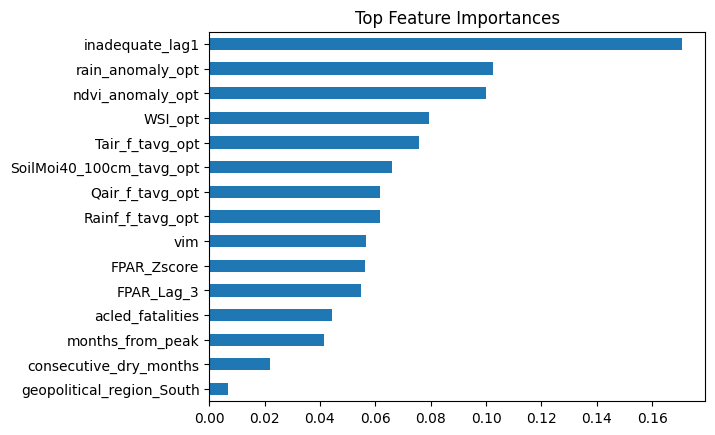


=== Forecast Error by State ===
               mean     std  count
NAME_1                            
Bauchi      -0.0547  0.1225     12
Jigawa      -0.0478  0.1271     12
Zamfara     -0.0429  0.1286     12
Rivers      -0.0391  0.1089     12
Niger       -0.0381  0.1643     12
Cross River -0.0373  0.1007     12
Katsina     -0.0368  0.1591     12
Taraba      -0.0357  0.1660     12
Akwa Ibom   -0.0357  0.1610     12
Abia        -0.0312  0.0691     12
Kano        -0.0308  0.1497     12
Nassarawa   -0.0307  0.0285      3
Edo         -0.0299  0.2097     12
Sokoto      -0.0298  0.1485     12
Kebbi       -0.0276  0.1575     12
Kwara       -0.0253  0.0844     12
Borno       -0.0251  0.0551     12
Benue       -0.0227  0.1535     12
Kogi        -0.0206  0.1268     12
Enugu       -0.0206  0.0877     12
Abuja       -0.0143  0.1228     12
Ogun        -0.0128  0.1260     12
Plateau     -0.0068  0.1154     12
Lagos       -0.0039  0.1136     12
Adamawa     -0.0022  0.0777     12
Yobe        -0.0021  0

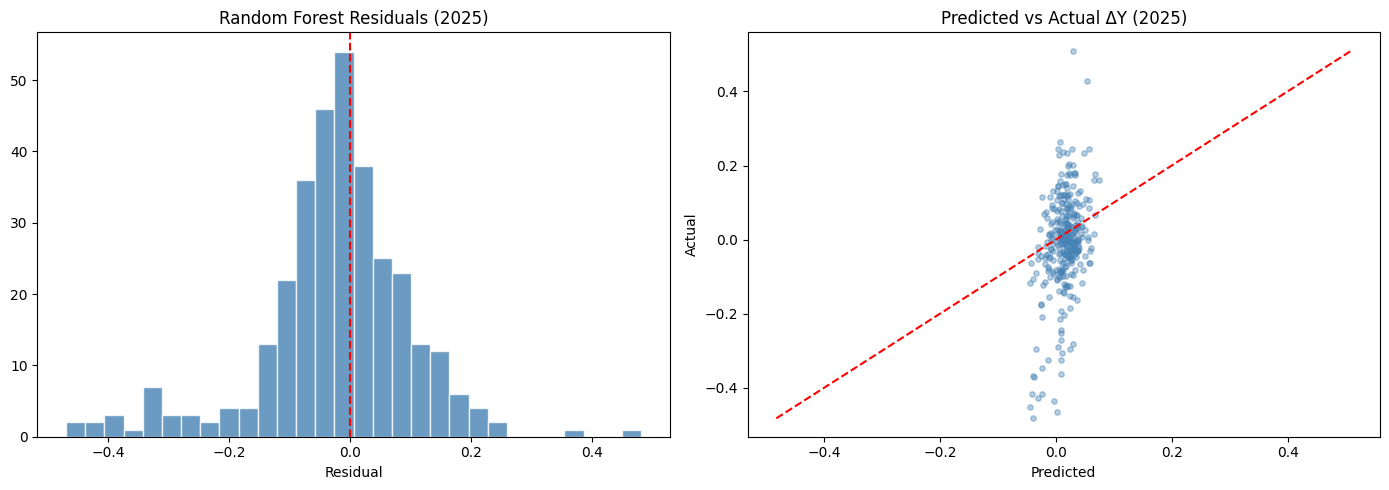

In [ ]:
# ── Feature importance ──

importances = best_model.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=X_selected.columns).sort_values(ascending=False)
print("=== Feature Importance (gain) ===")
print(feat_imp.head(15))


feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()


# ── Error by state ──
test_results = pd.DataFrame({
    'true': y_test.values, 'pred': y_pred
}, index=X_test.index)
test_results = test_results.join(df_ml.loc[X_test.index, ['NAME_1']], how='left')
test_results['error'] = test_results['true'] - test_results['pred']

error_by_state = (test_results.groupby('NAME_1')['error']
                  .agg(['mean', 'std', 'count'])
                  .sort_values('mean'))

print("\n=== Forecast Error by State ===")
print(error_by_state.round(4).to_string())

# ── Residual plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_results['error'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('Random Forest Residuals (2025)')
axes[0].set_xlabel('Residual')

axes[1].scatter(test_results['pred'], test_results['true'], alpha=0.4, s=15, color='steelblue')
lims = [min(test_results['pred'].min(), test_results['true'].min()),
        max(test_results['pred'].max(), test_results['true'].max())]
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_title('Predicted vs Actual ΔY (2025)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Add XGBoost to the comparison
baseline_results['Random Forest (tuned)'] = {
    'MAE' : mae_RF,
    'RMSE': rmse_RF,
    'R²'  : r2_RF,
}

summary = pd.DataFrame(baseline_results).T
summary['ΔRMSE vs RW'] = summary['RMSE'] - rmse_rw
summary['% gain vs RW'] = ((rmse_rw - summary['RMSE']) / rmse_rw * 100)

print("="*75)
print("   MODEL COMPARISON — All evaluated on 2025 out-of-sample")
print("="*75)
print(summary.round(4).to_string())
print("="*75)

# ── Interpretation ──
best_model_name = summary['RMSE'].idxmin()
best_rmse = summary['RMSE'].min()
RF_vs_rw = summary.loc['Random Forest (tuned)', '% gain vs RW']

print(f"\nBest model on 2025: {best_model_name} (RMSE = {best_rmse:.4f})")
print(f"Random Forest vs Random Walk: {RF_vs_rw:+.1f}%")

if RF_vs_rw < 0:
    print("\n⚠ Random Forest underperforms the random walk on 2025.")
    print("  Possible explanations:")
    print("  - Regime shift in 2025 (macro shocks not in X)")
    print("  - Overfitting on 2023-2024 training period")
    print("  - Features lose predictive power out-of-sample")
    print("  This is itself an informative result for the WFP.")
else:
    print(f"\n✓ Random Forest improves on baselines by {RF_vs_rw:.1f}%.")

   MODEL COMPARISON — All evaluated on 2025 out-of-sample
                          MAE    RMSE      R²  ΔRMSE vs RW  % gain vs RW
Random Walk (ΔŶ=0)     0.0903  0.1321 -0.0050       0.0000        0.0000
Seasonal Δ             0.0942  0.1296  0.0331      -0.0025        1.9161
ARMA (per state)       0.0903  0.1321 -0.0050       0.0000        0.0000
Lasso (linear)         0.0894  0.1260  0.0865      -0.0062        4.6608
Random Forest (tuned)  0.0889  0.1272  0.0683      -0.0049        3.7168

Best model on 2025: Lasso (linear) (RMSE = 0.1260)
Random Forest vs Random Walk: +3.7%

✓ Random Forest improves on baselines by 3.7%.


Les résultats mettent en évidence un biais systématique du modèle, qui tend à surestimer la variation de l’insécurité alimentaire dans l’ensemble des États analysés, comme l’indiquent les erreurs moyennes négatives. Autrement dit, le modèle prédit des détériorations plus importantes que celles réellement observées. Ce biais est particulièrement marqué dans des régions vulnérables comme Bauchi, Zamfara ou Niger, ce qui suggère que le modèle capte bien les zones à risque mais exagère l’intensité des chocs, probablement en raison de l’absence de variables reflétant les mécanismes d’adaptation locaux (résilience des populations, aides humanitaires, ajustements des marchés). Par ailleurs, la variabilité des erreurs diffère selon les États, certaines zones présentant des erreurs plus instables, ce qui traduit une hétérogénéité spatiale dans la performance du modèle. Globalement, ces résultats indiquent que si le modèle est pertinent pour identifier les dynamiques de risque, il reste limité dans sa capacité à en quantifier précisément l’ampleur.


# Forcasting

In [66]:
# Liste de tes cibles (Horizons)
horizons = {
    '1 Mois': 'delta_inadequate',
    '3 Mois': 'delta_inadequate_h3',
    '6 Mois': 'delta_inadequate_h6'
}
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

results_multi_h = {}

for nom_horizon, target_col in horizons.items():
    print(f"\n========================================")
    print(f" ENTRAÎNEMENT POUR HORIZON : {nom_horizon}")
    print(f"========================================")
    
    # 1. Nettoyer les NaNs spécifiques à cet horizon
    df_h = df.dropna(subset=[target_col, 'inadequate'] + features_base).copy()
    
    # 2. Refaire ton Split (Train 2023-2024 / Test 2025)
    mask_train_h = (df_h['time'] < date_coupure).values
    mask_test_h  = (df_h['time'] >= date_coupure).values
    
    X_raw_h = pd.get_dummies(df_h[X_cols], drop_first=True)
    y_del_h = df_h[target_col]
    
    X_train_full_h = X_raw_h.loc[mask_train_h].copy()
    X_test_full_h  = X_raw_h.loc[mask_test_h].copy()
    y_train_h = y_del_h.loc[mask_train_h]
    y_test_h  = y_del_h.loc[mask_test_h]
    
    # 3. Imputation (sur Train)
    for c in X_train_full_h.columns[X_train_full_h.isna().any()]:
        train_median = X_train_full_h[c].median()
        X_train_full_h[c] = X_train_full_h[c].fillna(train_median)
        X_test_full_h[c]  = X_test_full_h[c].fillna(train_median)
        
    # 4. Lasso (Sélection de variables propre à cet horizon)
    scaler_h = StandardScaler()
    X_train_scaled_h = scaler_h.fit_transform(X_train_full_h)
    
    lasso_h = LassoCV(cv=TimeSeriesSplit(n_splits=5), max_iter=10000, random_state=42)
    lasso_h.fit(X_train_scaled_h, y_train_h)
    
    # Récupérer les variables qui survivent pour CET horizon
    selected_features_h = X_train_full_h.columns[lasso_h.coef_ != 0].tolist()
    print(f"Variables sélectionnées par Lasso pour {nom_horizon}: {len(selected_features_h)}")
    
    if len(selected_features_h) == 0:
        print("Lasso a tout annulé (Signal trop faible).")
        continue
        
    X_train_xgb_h = X_train_full_h[selected_features_h]
    X_test_xgb_h  = X_test_full_h[selected_features_h]
    

    # 5. XGBoost (Avec ta grille hyper-régularisée)
    model_h = RandomForestRegressor(random_state=42)
    grid_search_h = GridSearchCV(
        estimator=model_h,
        param_grid=param_grid,
        cv=TimeSeriesSplit(n_splits=5),
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    grid_search_h.fit(X_train_xgb_h, y_train_h)

    best_model_h = grid_search_h.best_estimator_
    y_pred_h = best_model_h.predict(X_test_xgb_h)
    
    # 6. Sauvegarde des résultats
    rmse_test = mean_squared_error(y_test_h, y_pred_h) ** 0.5
    rmse_cv = (-grid_search_h.best_score_)**0.5
    
    results_multi_h[nom_horizon] = {'RMSE_CV': rmse_cv, 'RMSE_Test_2025': rmse_test}
    print(f"RMSE CV: {rmse_cv:.4f} | RMSE Test (2025): {rmse_test:.4f}")

# Affichage final comparatif
pd.DataFrame(results_multi_h).T


    


 ENTRAÎNEMENT POUR HORIZON : 1 Mois
Variables sélectionnées par Lasso pour 1 Mois: 15
Fitting 5 folds for each of 108 candidates, totalling 540 fits
RMSE CV: 0.0553 | RMSE Test (2025): 0.1272

 ENTRAÎNEMENT POUR HORIZON : 3 Mois
Variables sélectionnées par Lasso pour 3 Mois: 16
Fitting 5 folds for each of 108 candidates, totalling 540 fits
RMSE CV: 0.0732 | RMSE Test (2025): 0.2349

 ENTRAÎNEMENT POUR HORIZON : 6 Mois
Variables sélectionnées par Lasso pour 6 Mois: 18
Fitting 5 folds for each of 108 candidates, totalling 540 fits
RMSE CV: 0.1230 | RMSE Test (2025): 0.2472


,RMSE_CV,RMSE_Test_2025
1 Mois,0.055271,0.127227
3 Mois,0.073241,0.234931
6 Mois,0.123035,0.247204


In [67]:
for nom_horizon, target_col in horizons.items():
    # Utiliser df au lieu de df_ml
    mask_test_df = (df['time'] >= date_coupure)
    y_test_h = df.loc[mask_test_df, target_col].dropna()
    rw_rmse = np.sqrt(mean_squared_error(y_test_h, np.zeros(len(y_test_h))))
    
    xgb_rmse = results_multi_h[nom_horizon]['RMSE_Test_2025']
    
    gain = (rw_rmse - xgb_rmse) / rw_rmse * 100
    print(f"{nom_horizon}: RW RMSE = {rw_rmse:.4f} | XGB RMSE = {xgb_rmse:.4f} | Gain = {gain:+.1f}%")

1 Mois: RW RMSE = 0.1321 | XGB RMSE = 0.1272 | Gain = +3.7%
3 Mois: RW RMSE = 0.2429 | XGB RMSE = 0.2349 | Gain = +3.3%
6 Mois: RW RMSE = 0.2646 | XGB RMSE = 0.2472 | Gain = +6.6%


In [ ]:
from sklearn.neural_network import MLPRegressor

In [50]:
pipeline_1 = Pipeline([
    ("preprocess", preprocessor),
    ("model", MLPRegressor(max_iter=500, random_state=42))
])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "model__activation": ["identity", "logistic", "tanh", "relu"],
    "model__hidden_layer_sizes": [(100,), (150,), (200,)],
    "model__alpha": [0.0001, 0.001, 0.01] 
}

grid = GridSearchCV(
    pipeline_1,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# Résultats
print("Best params:", grid.best_params_)
print("Best RMSE:", np.sqrt(-grid.best_score_))

NameError: name 'MLPRegressor' is not defined

In [ ]:
from sklearn.linear_model import ElasticNet

pipeline_enet = Pipeline([
    ("preprocess", preprocessor),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000))
])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

grid_enet = GridSearchCV(
    pipeline_enet,
    param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_enet.fit(X_train, y_train)

best_model = grid_enet.best_estimator_

# Evaluation
y_pred = best_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best params:", grid_enet.best_params_)
print("RMSE:", rmse)
print("R2:", r2)

Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
RMSE: 0.13075541485921202
R2: 0.015916768466535225
